# 0. Import libraries and data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data_path = './data'

df_2022 = pd.read_csv(f"{data_path}/2022/heart_2022_with_nans.csv")
df_2020 = pd.read_csv(f"{data_path}/2020/heart_2020_cleaned.csv")

# 1. Data analysis

## 1.1 Start with looking at the data columns, info, etc..

In [4]:
df_2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

In [5]:
df_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

## 1.2 Then find missing values, NAN or NULL

In [11]:
df_2020.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [12]:
df_2022.isnull().sum()

State                            0
Sex                              0
GeneralHealth                 1198
PhysicalHealthDays           10927
MentalHealthDays              9067
LastCheckupTime               8308
PhysicalActivities            1093
SleepHours                    5453
RemovedTeeth                 11360
HadHeartAttack                3065
HadAngina                     4405
HadStroke                     1557
HadAsthma                     1773
HadSkinCancer                 3143
HadCOPD                       2219
HadDepressiveDisorder         2812
HadKidneyDisease              1926
HadArthritis                  2633
HadDiabetes                   1087
DeafOrHardOfHearing          20647
BlindOrVisionDifficulty      21564
DifficultyConcentrating      24240
DifficultyWalking            24012
DifficultyDressingBathing    23915
DifficultyErrands            25656
SmokerStatus                 35462
ECigaretteUsage              35660
ChestScan                    56046
RaceEthnicityCategor

## 1.2.1 Do some prelimary data cleaning - Remove samples with empty data

In [46]:
# def remove_columns(df, threshold=20):
#     print(f"Before: {df.shape}")
#     # Calculate the % of missing vals in each column
#     missing_percentage = df.isnull().mean() * 100
#     columns_to_drop = missing_percentage[missing_percentage > threshold].index
#     # Drop the columns with too many missing vals
#     df_cleaned = df.drop(columns=columns_to_drop)
    
#     print(f"Dropped {len(columns_to_drop)} columns")
#     print(f"Columns dropped: {', '.join(columns_to_drop)}")
#     print(f"After: {df_cleaned.shape}")
    
#     return df_cleaned

# train_df_cleaned = remove_columns(train_df, threshold=20)


Before: (8921483, 83)
Dropped 9 columns
Columns dropped: DefaultBrowsersIdentifier, OrganizationIdentifier, PuaMode, SmartScreen, Census_ProcessorClass, Census_InternalBatteryType, Census_IsFlightingInternal, Census_ThresholdOptIn, Census_IsWIMBootEnabled
After: (8921483, 74)


## 1.3 Data distribution for the 2020 heart disease dataframe

For train set

HasDetections
0    4462591
1    4458892
Name: count, dtype: int64


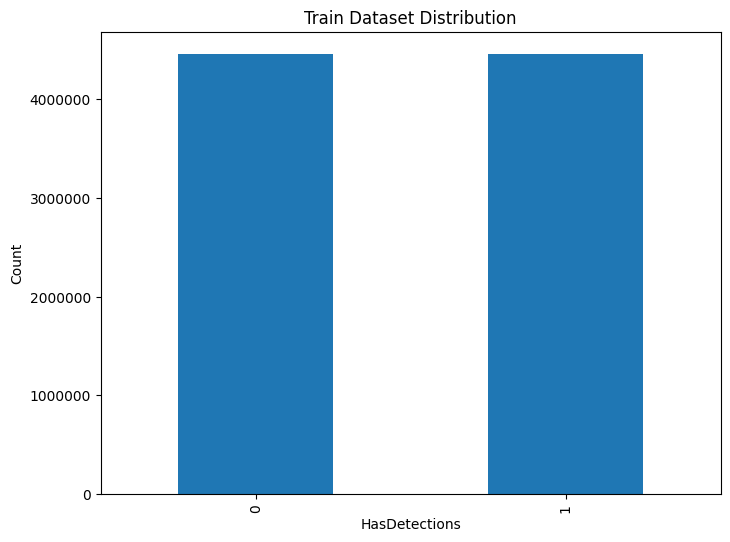

In [48]:
print(df_2020['HasDetections'].value_counts())

plt.figure(figsize=(8, 6))
df_2020['HasDetections'].value_counts().plot(kind='bar')
plt.title('Train Dataset Distribution')
plt.xlabel('HasDetections')
plt.ylabel('Count')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

## 1.4 Analyze different columns


Analysis of column name: ProductName:

Top 3 common values:
ProductName
win8defender     8826520
mse                94873
mseprerelease         53
Name: count, dtype: int64


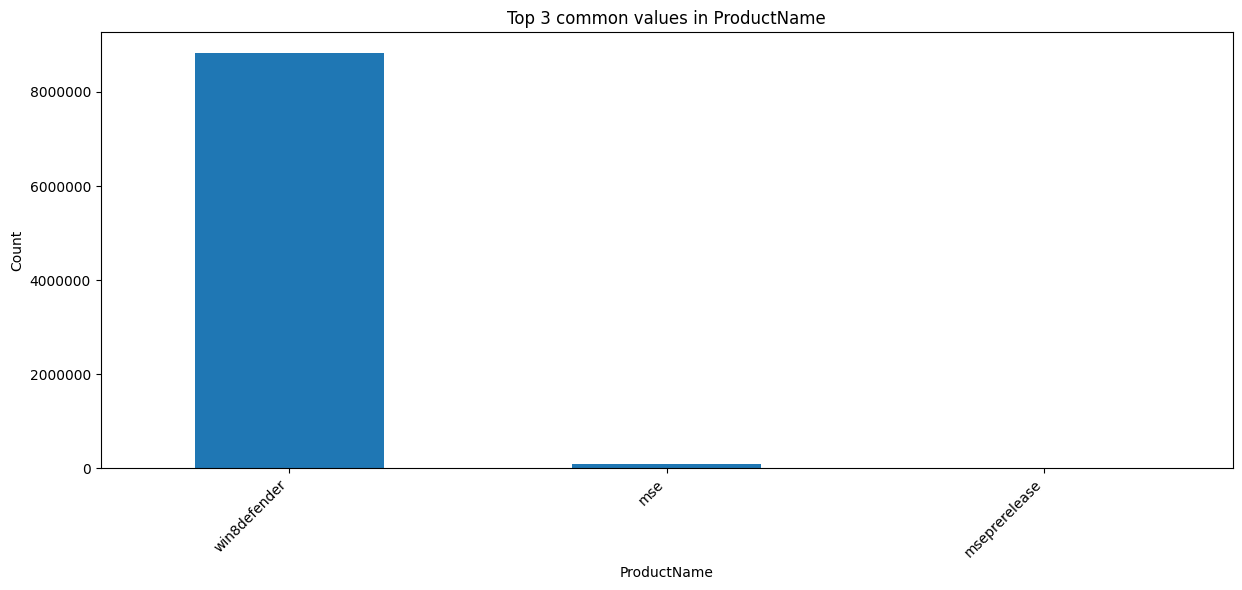


Analysis of column name: AVProductsInstalled:

Top 3 common values:
AVProductsInstalled
1.0    6208893
2.0    2459008
3.0     208103
Name: count, dtype: int64


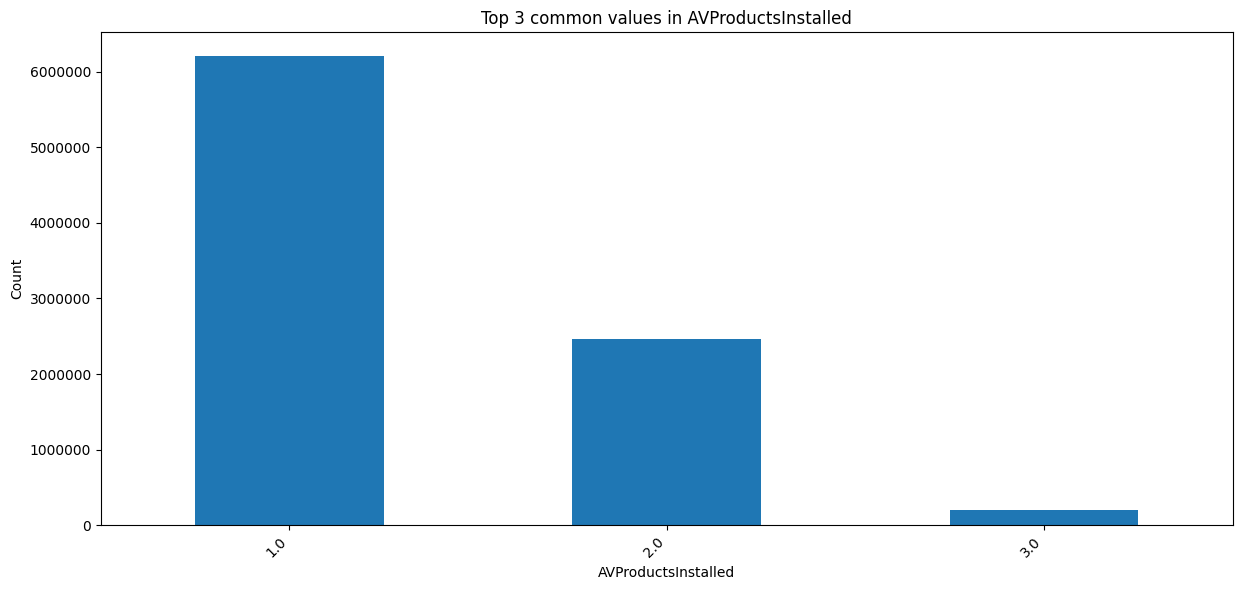


Analysis of column name: AVProductsEnabled:

Top 3 common values:
AVProductsEnabled
1.0    8654101
2.0     198652
UNK      36221
Name: count, dtype: int64


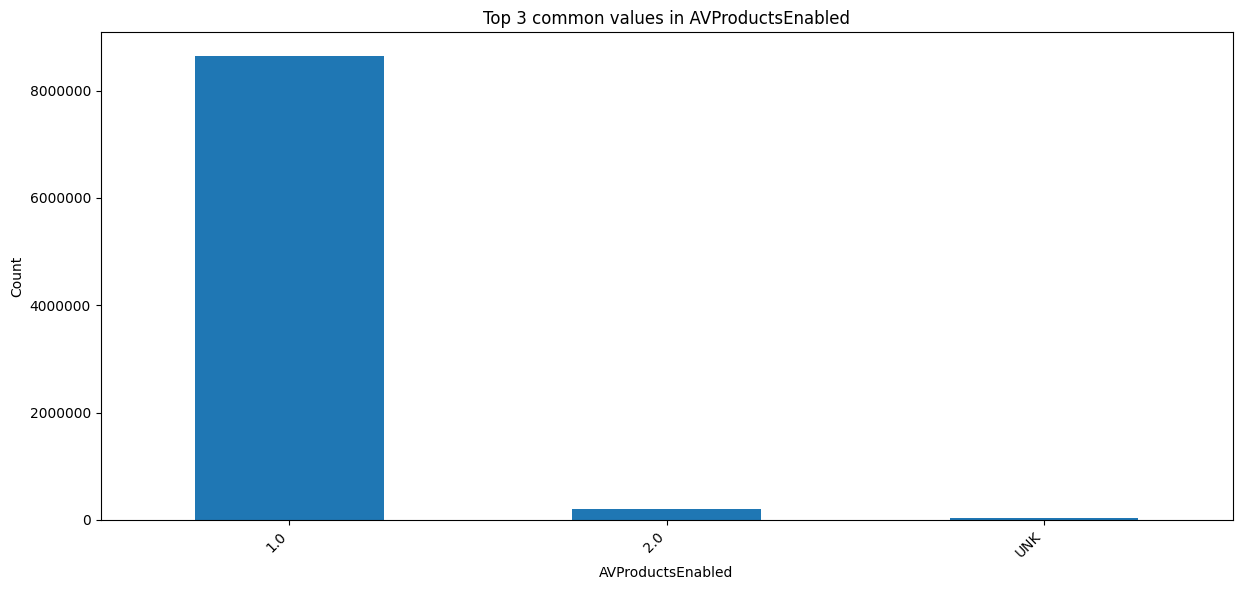


Analysis of column name: Platform:

Top 3 common values:
Platform
windows10    8618715
windows8      194508
windows7       93889
Name: count, dtype: int64


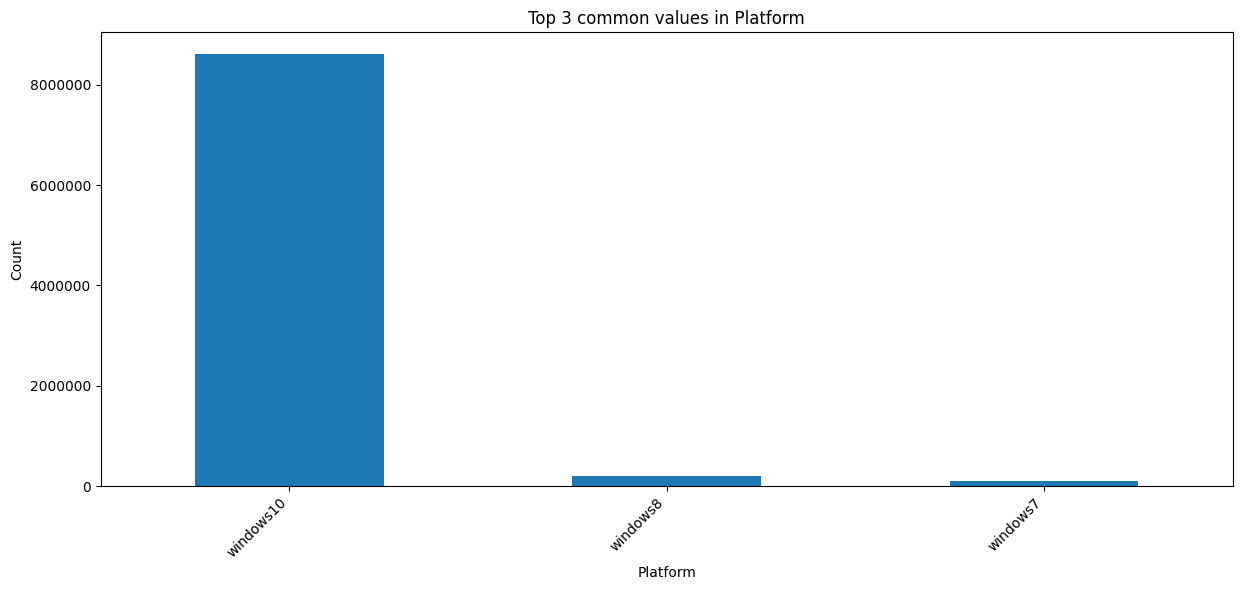


Analysis of column name: Processor:

Top 3 common values:
Processor
x64      8105435
x86       815702
arm64        346
Name: count, dtype: int64


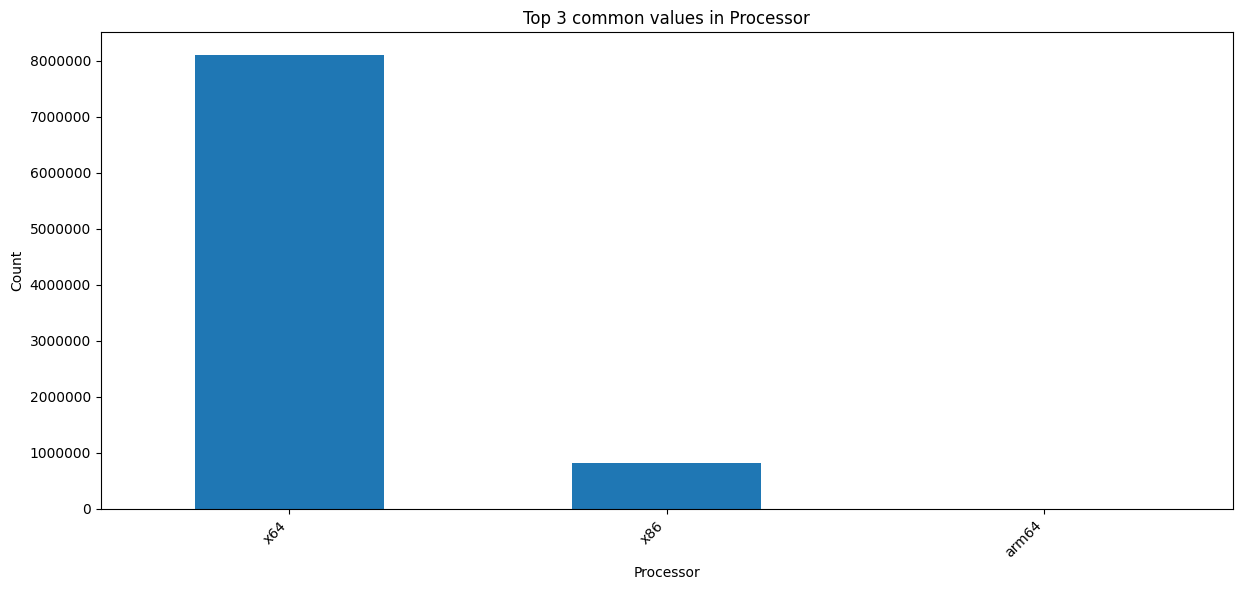


Analysis of column name: IsProtected:

Top 3 common values:
IsProtected
1.0    8402282
0.0     483157
UNK      36044
Name: count, dtype: int64


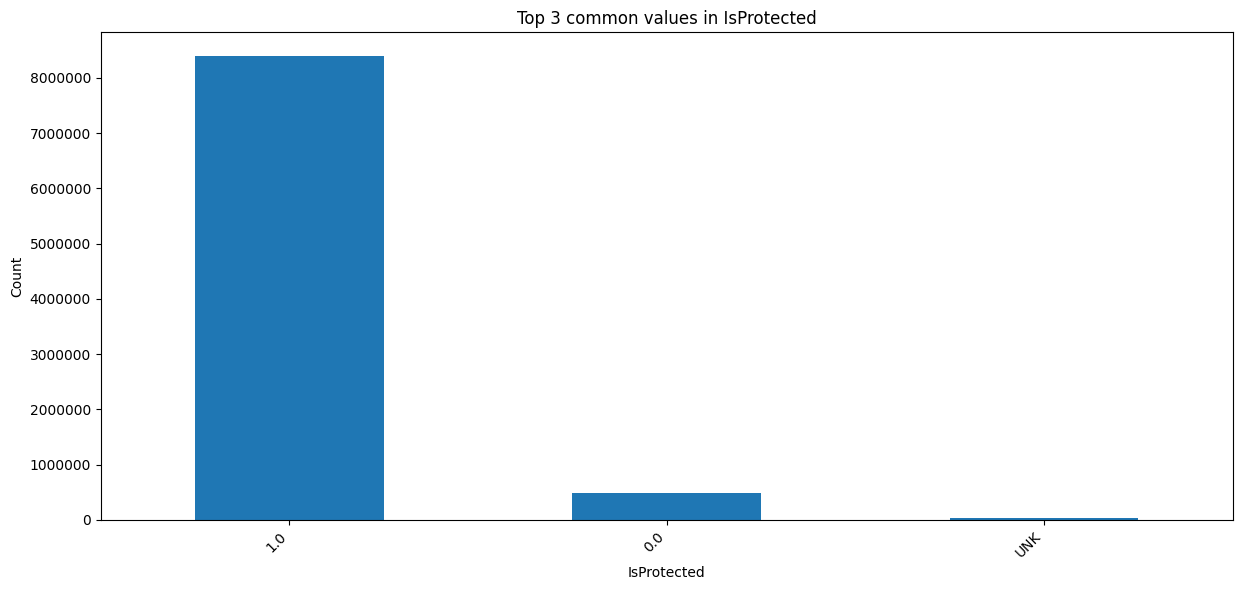


Analysis of column name: Firewall:

Top 3 common values:
Firewall
1.0    8641014
0.0     189119
UNK      91350
Name: count, dtype: int64


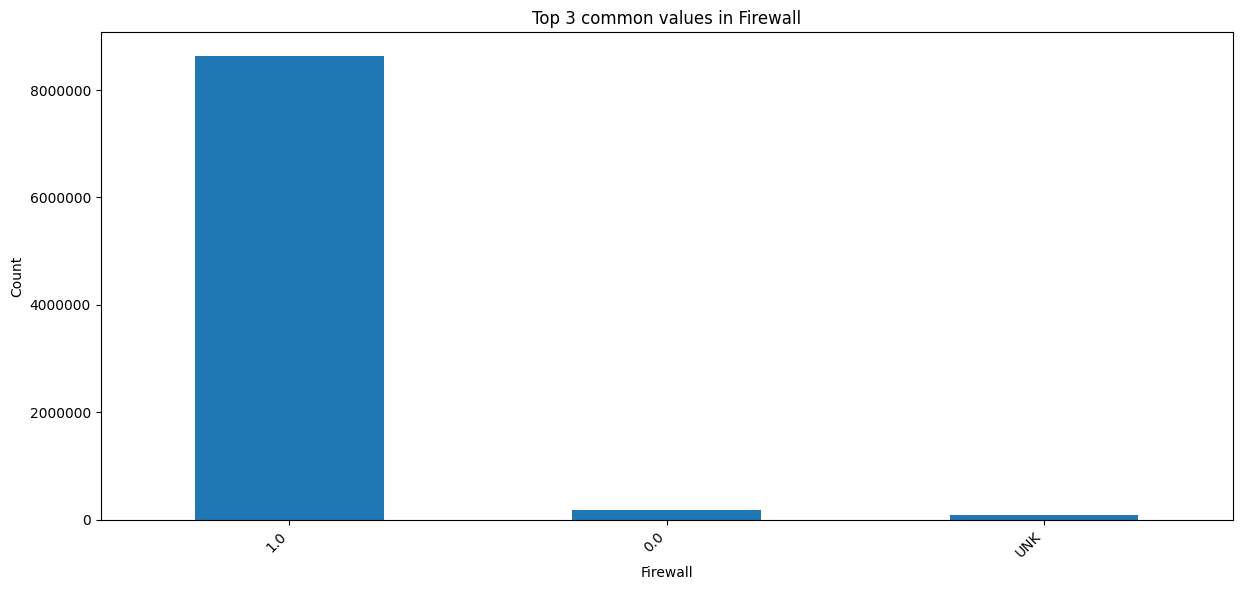

In [50]:
def column_analyze(df, column, top_n=3):
    print(f"\nAnalysis of column name: {column}:")
    value_counts = df[column].value_counts()
    print(f"\nTop {top_n} common values:")
    print(value_counts.head(top_n))
    
    plt.figure(figsize=(12, 6))
    value_counts.head(top_n).plot(kind='bar')
    plt.title(f'Top {top_n} common values in {column}')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.ticklabel_format(style='plain', axis='y')

    plt.show()
    
categorical_columns = ['ProductName', 'AVProductsInstalled', 'AVProductsEnabled', 'Platform', 'Processor', 'IsProtected', 'Firewall']
for column in categorical_columns:
    column_analyze(df_cleaned, column)

## 2. Analyze feature importance

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [54]:
def calculate_feature_importance(df, target_column='HasDetections', n_estimators=100, random_state=42):
    """
    Calculate feature importance using Random Forest classifier.
    
    Args:
    df (pandas.DataFrame): Input dataframe
    target_column (str): Name of the target column
    n_estimators (int): Number of trees in the forest
    random_state (int): Random state for reproducibility
    
    Returns:
    pandas.DataFrame: DataFrame with feature importances
    """
    # Separate features and target
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    # Encode categorical variables
    le = LabelEncoder()
    for column in X.select_dtypes(include=['object']):
        X[column] = le.fit_transform(X[column].astype(str))
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
    
    # Create and train the model
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    rf.fit(X_train, y_train)
    
    # Get feature importances
    importances = rf.feature_importances_
    feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importances})
    feature_importance = feature_importance.sort_values('importance', ascending=False).reset_index(drop=True)
    
    return feature_importance

def plot_feature_importance(feature_importance, top_n=20):
    """
    Plot top N important features.
    
    Args:
    feature_importance (pandas.DataFrame): DataFrame with feature importances
    top_n (int): Number of top features to plot
    """
    plt.figure(figsize=(10, 8))
    plt.title(f'Top {top_n} Feature Importance')
    plt.bar(range(top_n), feature_importance['importance'][:top_n])
    plt.xticks(range(top_n), feature_importance['feature'][:top_n], rotation=90)
    plt.tight_layout()
    plt.show()

# Usage
feature_importance = calculate_feature_importance(df_cleaned)
plot_feature_importance(feature_importance)

# Print top 20 important features
print("Top 20 important features:")
print(feature_importance.head(20))

MemoryError: could not allocate 268435456 bytes